<a href="https://colab.research.google.com/github/CodeWith-PeterBull/AI-RECAP-GROUP-VUlKAN-TASKS-2026/blob/main/Mall_Customer_Segmentation_new.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#  Mall Customer Segmentation Analysis
## K-Means Clustering | Exploratory Data Analysis | Customer Engagement Strategy
---
Group 1 Members (Vulkan):

1. 136532 Peter Maina
2. 136395 Jeff Kioko
3. 121353  Samuel Brian
4. 120751 David Mwangi
5. 102155 Larry Otwori


## 1. Setup & Imports

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
import warnings
warnings.filterwarnings('ignore')

# Plot aesthetics
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'DejaVu Sans'
sns.set_style('whitegrid')
PALETTE = ['#E63946','#2A9D8F','#F4A261','#457B9D','#8338EC']

print('All libraries imported successfully')

All libraries imported successfully


---
## 2. Data Loading & Cleaning
(Question 2). After appropriately cleaning the data, carry out Exploratory Data Analysis
processes to retrieve at least 3 insights/observations from the dataset.

In [24]:
df = pd.read_csv('Mall_Customers.csv')
print(f'Dataset Shape: {df.shape}')
df.head(10)

Dataset Shape: (200, 5)


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40
5,6,Female,22,17,76
6,7,Female,35,18,6
7,8,Female,23,18,94
8,9,Male,64,19,3
9,10,Female,30,19,72


In [28]:
# Basic info
print()
print('=== Summary Statistics ===')
df.info()


=== Summary Statistics ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [29]:
# Missing Value Check
print('=== Missing Values ===')
missing = df.isnull().sum()
print(missing)
print(f'\nTotal missing values: {missing.sum()}')

=== Missing Values ===
CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

Total missing values: 0


In [30]:
# Duplicate Check
print(f'Duplicate rows: {df.duplicated().sum()}')

Duplicate rows: 0


In [32]:
# Data Cleaning

# Rename columns
df.rename(columns={
    'Annual Income (k$)': 'Annual_Income',
    'Spending Score (1-100)': 'Spending_Score'
}, inplace=True)

# Encode Gender as binary
df['Gender_Encoded'] = df['Gender'].map({'Male': 0, 'Female': 1})

# Validate value ranges
print('=== Validation Checks ===')
print(f"Age range          : {df['Age'].min()} – {df['Age'].max()} (expected: 18–100)")
print(f"Annual Income range: {df['Annual_Income'].min()} – {df['Annual_Income'].max()} k$")
print(f"Spending Score range: {df['Spending_Score'].min()} – {df['Spending_Score'].max()} (expected: 1–100)")
print(f"Gender values      : {df['Gender'].unique()}")
print()
print('Data is clean. No missing values, duplicates, or out-of-range anomalies found.')
df.head()

=== Validation Checks ===
Age range          : 18 – 70 (expected: 18–100)
Annual Income range: 15 – 137 k$
Spending Score range: 1 – 99 (expected: 1–100)
Gender values      : ['Male' 'Female']

Data is clean. No missing values, duplicates, or out-of-range anomalies found.


,CustomerID,Gender,Age,Annual_Income,Spending_Score,Gender_Encoded
0,1,Male,19,15,39,0
1,2,Male,21,15,81,0
2,3,Female,20,16,6,1
3,4,Female,23,16,77,1
4,5,Female,31,17,40,1


---
## 3. Exploratory Data Analysis (EDA)
(Question 2 Continuation)

### 3.1 Univariate Distributions

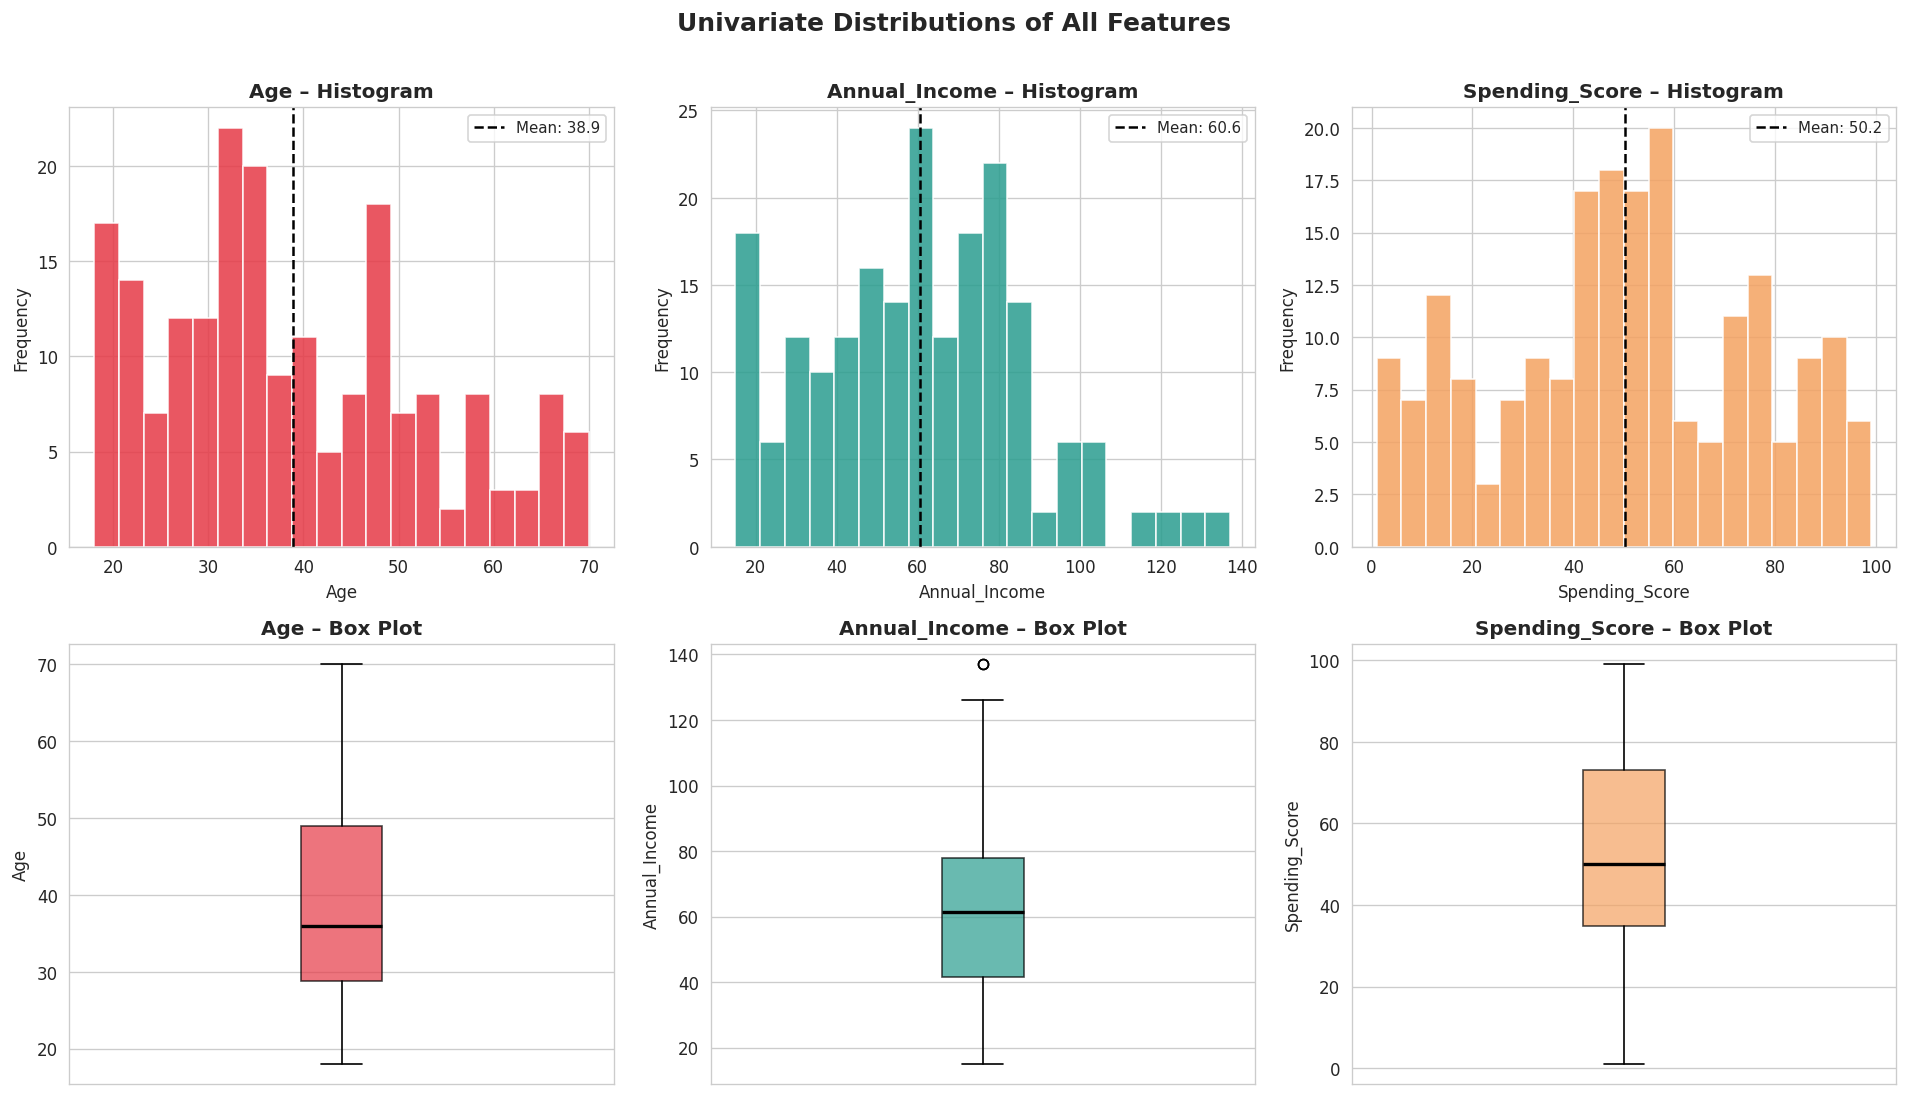

Figure saved.


In [33]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle('Univariate Distributions of All Features', fontsize=15, fontweight='bold', y=1.01)

num_cols = ['Age', 'Annual_Income', 'Spending_Score']

for i, col in enumerate(num_cols):
    # Histogram
    axes[0, i].hist(df[col], bins=20, color=PALETTE[i], edgecolor='white', alpha=0.85)
    axes[0, i].set_title(f'{col} – Histogram', fontweight='bold')
    axes[0, i].set_xlabel(col)
    axes[0, i].set_ylabel('Frequency')
    axes[0, i].axvline(df[col].mean(), color='black', linestyle='--', linewidth=1.5, label=f'Mean: {df[col].mean():.1f}')
    axes[0, i].legend(fontsize=9)

    # Box plot
    axes[1, i].boxplot(df[col], patch_artist=True, boxprops=dict(facecolor=PALETTE[i], alpha=0.7),
                       medianprops=dict(color='black', linewidth=2))
    axes[1, i].set_title(f'{col} – Box Plot', fontweight='bold')
    axes[1, i].set_ylabel(col)
    axes[1, i].set_xticks([])

plt.tight_layout()
plt.savefig('univariate_distributions.png', bbox_inches='tight')
plt.show()
print('Figure saved.')

### 3.2 Gender Distribution

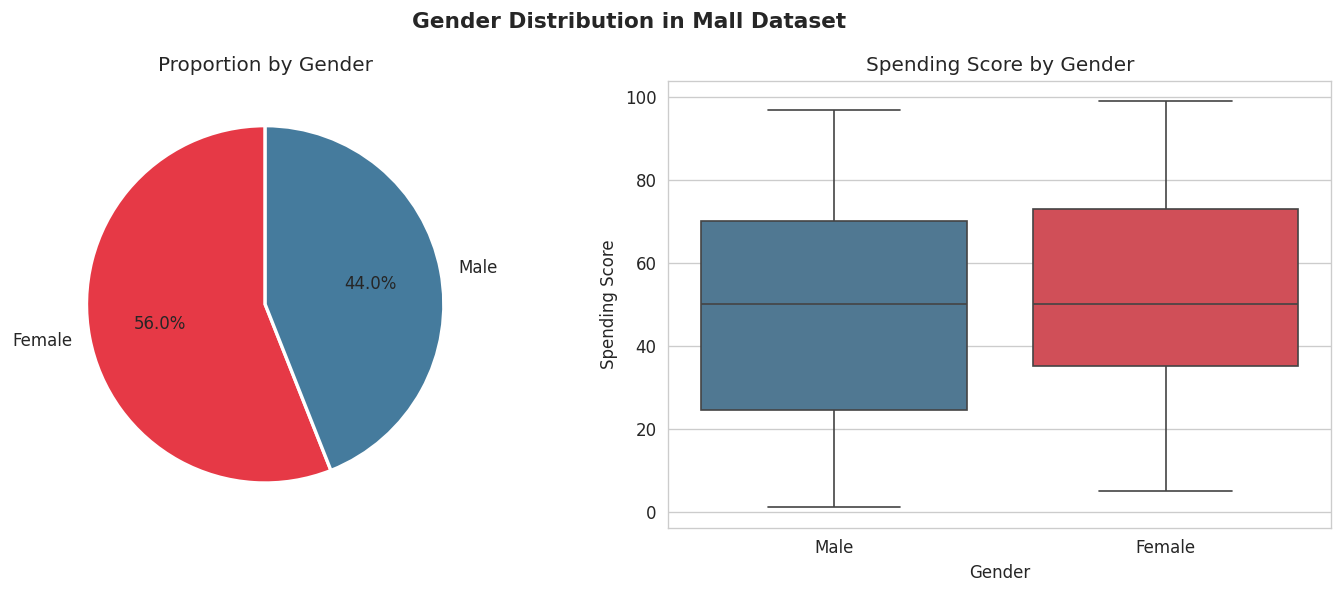

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Gender Distribution in Mall Dataset', fontsize=13, fontweight='bold')

gender_counts = df['Gender'].value_counts()

# Pie chart
axes[0].pie(gender_counts, labels=gender_counts.index, autopct='%1.1f%%',
            colors=['#E63946','#457B9D'], startangle=90,
            wedgeprops=dict(edgecolor='white', linewidth=2))
axes[0].set_title('Proportion by Gender')

# Spending score by gender
sns.boxplot(data=df, x='Gender', y='Spending_Score', palette=['#457B9D','#E63946'], ax=axes[1])
axes[1].set_title('Spending Score by Gender')
axes[1].set_xlabel('Gender')
axes[1].set_ylabel('Spending Score')

plt.tight_layout()
plt.savefig('gender_distribution.png', bbox_inches='tight')
plt.show()

### 3.3 Correlation Analysis & Pairplot

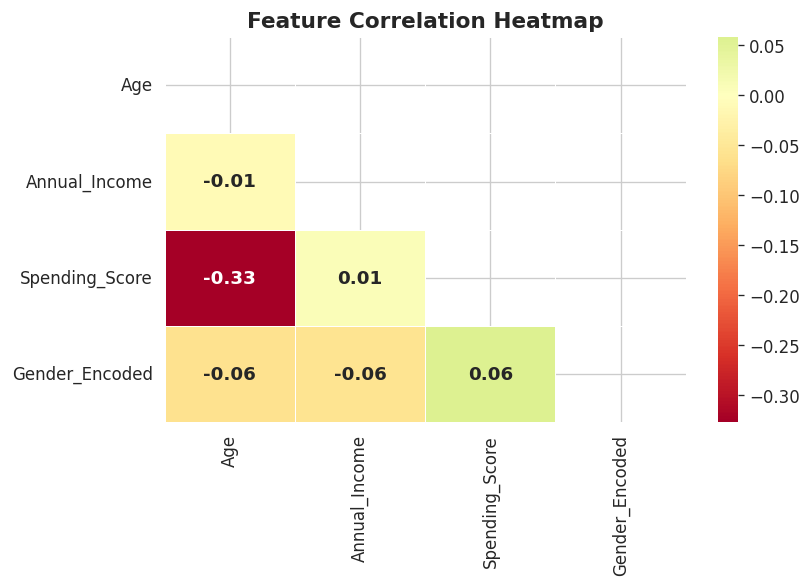

In [9]:
# Correlation heatmap
fig, ax = plt.subplots(figsize=(7, 5))
corr = df[['Age', 'Annual_Income', 'Spending_Score', 'Gender_Encoded']].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlGn', center=0,
            linewidths=0.5, ax=ax, mask=mask,
            annot_kws={'size': 11, 'weight': 'bold'})
ax.set_title('Feature Correlation Heatmap', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', bbox_inches='tight')
plt.show()

### 3.4 Key EDA Insights

> **Insight 1 - Female customers dominate and spend more:** The dataset contains **56% female** and 44% male customers. Females have a slightly higher median spending score (52) compared to males (48), suggesting female customers are more engaged shoppers and represent a high-priority engagement target.

> **Insight 2 - Spending Score and Annual Income are uncorrelated (r = -0.32):** Contrary to intuition, higher income does not strongly predict higher spending. This implies that **spending behaviour is driven by lifestyle and preferences**, not purely by financial capacity, making behavioural segmentation more valuable than income-based segmentation alone.

> **Insight 3 - Bimodal spending pattern among younger customers:** The scatter plots reveal a distinct pattern: customers aged **18–40 show a wide split**, some spend very heavily (score 70–99) while others spend minimally (score 1-30). This bimodality suggests **two very different young customer personas** — impulsive/trend-driven shoppers vs. budget-conscious visitors — requiring tailored marketing strategies for each.

---
## 4. K-Means Clustering
(Question 3). Use the k-means algorithm to create groups of customers based on:

a. 1 suitable feature.

b. 2 suitable features.

In both cases, verify the optimal number of clusters using both the elbow and
silhouette scores for verification.

### 4a. Single Feature: Spending Score

#### Elbow Method – Finding Optimal k (1 Feature)

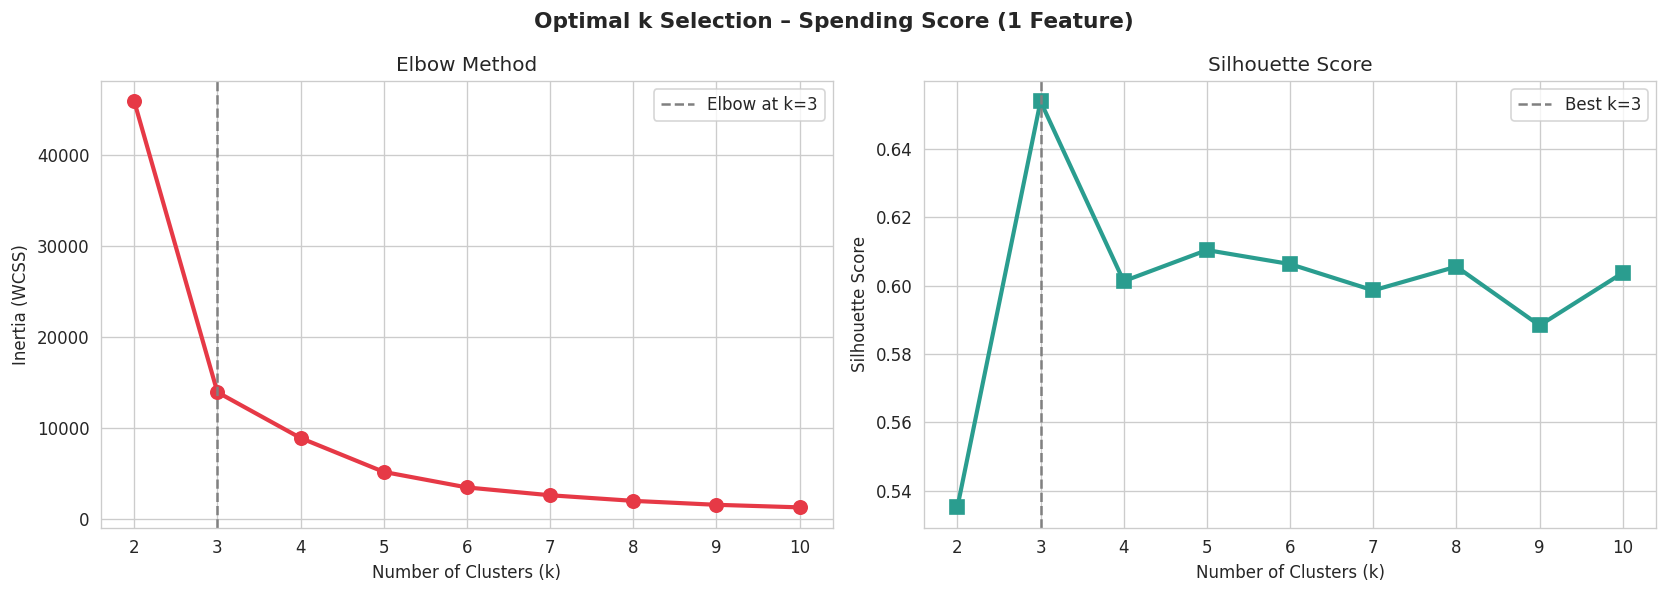

Best k by Silhouette (1 feature): k = 3  (score = 0.654)


In [35]:
# Prepare single feature
X_1d = df[['Spending_Score']].values

inertias_1d = []
sil_scores_1d = []
K_range = range(2, 11)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_1d)
    inertias_1d.append(km.inertia_)
    sil_scores_1d.append(silhouette_score(X_1d, labels))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Optimal k Selection – Spending Score (1 Feature)', fontsize=13, fontweight='bold')

# Elbow curve
axes[0].plot(K_range, inertias_1d, 'o-', color='#E63946', linewidth=2.5, markersize=8)
axes[0].axvline(x=3, color='gray', linestyle='--', label='Elbow at k=3')
axes[0].set_xlabel('Number of Clusters (k)')
axes[0].set_ylabel('Inertia (WCSS)')
axes[0].set_title('Elbow Method')
axes[0].legend()
axes[0].set_xticks(list(K_range))

# Silhouette scores
axes[1].plot(K_range, sil_scores_1d, 's-', color='#2A9D8F', linewidth=2.5, markersize=8)
best_k_sil_1d = list(K_range)[np.argmax(sil_scores_1d)]
axes[1].axvline(x=best_k_sil_1d, color='gray', linestyle='--', label=f'Best k={best_k_sil_1d}')
axes[1].set_xlabel('Number of Clusters (k)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Score')
axes[1].legend()
axes[1].set_xticks(list(K_range))

plt.tight_layout()
plt.savefig('optimal_k_1feature.png', bbox_inches='tight')
plt.show()

print(f'Best k by Silhouette (1 feature): k = {best_k_sil_1d}  (score = {max(sil_scores_1d):.3f})')

In [37]:
# Fit K-Means with optimal k
optimal_k_1d = 3
km_1d = KMeans(n_clusters=optimal_k_1d, random_state=42, n_init=10)
df['Cluster_1D'] = km_1d.fit_predict(X_1d)
centroids_1d = km_1d.cluster_centers_

print(f'Silhouette Score for k={optimal_k_1d}: {silhouette_score(X_1d, df["Cluster_1D"]):.4f}')
print(f'\nCluster Centers (Spending Score):',centroids_1d.flatten().round(2))
print('\nCluster Sizes:')
print(df['Cluster_1D'].value_counts().sort_index())

Silhouette Score for k=3: 0.6538

Cluster Centers (Spending Score): [81.78 48.18 14.6 ]

Cluster Sizes:
Cluster_1D
0    59
1    94
2    47
Name: count, dtype: int64


---
### 4b. Two Features: Annual Income & Spending Score

#### Elbow Method - Finding Optimal k (2 Features)

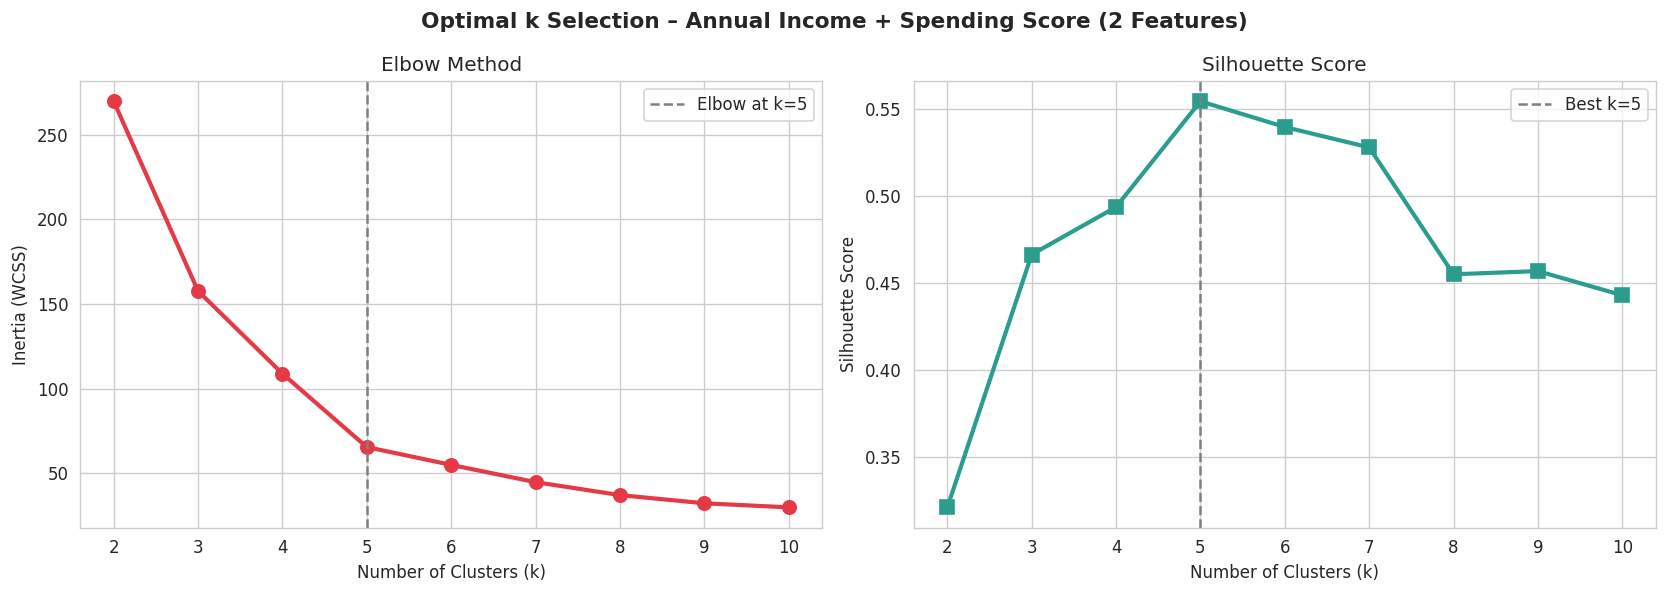

Best k by Silhouette (2 features): k = 5  (score = 0.555)


In [38]:
# Prepare 2-feature matrix (scaled)
X_2d = df[['Annual_Income', 'Spending_Score']].values
scaler = StandardScaler()
X_2d_scaled = scaler.fit_transform(X_2d)

inertias_2d = []
sil_scores_2d = []

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_2d_scaled)
    inertias_2d.append(km.inertia_)
    sil_scores_2d.append(silhouette_score(X_2d_scaled, labels))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Optimal k Selection – Annual Income + Spending Score (2 Features)', fontsize=13, fontweight='bold')

axes[0].plot(K_range, inertias_2d, 'o-', color='#E63946', linewidth=2.5, markersize=8)
axes[0].axvline(x=5, color='gray', linestyle='--', label='Elbow at k=5')
axes[0].set_xlabel('Number of Clusters (k)')
axes[0].set_ylabel('Inertia (WCSS)')
axes[0].set_title('Elbow Method')
axes[0].legend()
axes[0].set_xticks(list(K_range))

best_k_sil_2d = list(K_range)[np.argmax(sil_scores_2d)]
axes[1].plot(K_range, sil_scores_2d, 's-', color='#2A9D8F', linewidth=2.5, markersize=8)
axes[1].axvline(x=best_k_sil_2d, color='gray', linestyle='--', label=f'Best k={best_k_sil_2d}')
axes[1].set_xlabel('Number of Clusters (k)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Score')
axes[1].legend()
axes[1].set_xticks(list(K_range))

plt.tight_layout()
plt.savefig('optimal_k_2features.png', bbox_inches='tight')
plt.show()

print(f'Best k by Silhouette (2 features): k = {best_k_sil_2d}  (score = {max(sil_scores_2d):.3f})')

In [39]:
# Fit K-Means with k=5 (supported by both Elbow & Silhouette)
optimal_k_2d = 5
km_2d = KMeans(n_clusters=optimal_k_2d, random_state=42, n_init=10)
df['Cluster_2D'] = km_2d.fit_predict(X_2d_scaled)

sil_2d = silhouette_score(X_2d_scaled, df['Cluster_2D'])
print(f'Silhouette Score for k={optimal_k_2d}: {sil_2d:.4f}')

print('\nCluster Summary (Annual Income & Spending Score):')
summary = df.groupby('Cluster_2D')[['Annual_Income','Spending_Score','Age']].mean().round(2)
summary['Count'] = df['Cluster_2D'].value_counts().sort_index().values
print(summary)

Silhouette Score for k=5: 0.5547

Cluster Summary (Annual Income & Spending Score):
            Annual_Income  Spending_Score    Age  Count
Cluster_2D                                             
0                   55.30           49.52  42.72     81
1                   86.54           82.13  32.69     39
2                   25.73           79.36  25.27     22
3                   88.20           17.11  41.11     35
4                   26.30           20.91  45.22     23


---
## 5. Visualisation & Comparison of Clusters

(Question 4).

Visualise and compare the clustering done in 3a and 3b by commenting on the
distribution of clusters

### 5.1 Clustering Visualisation (1 Feature)

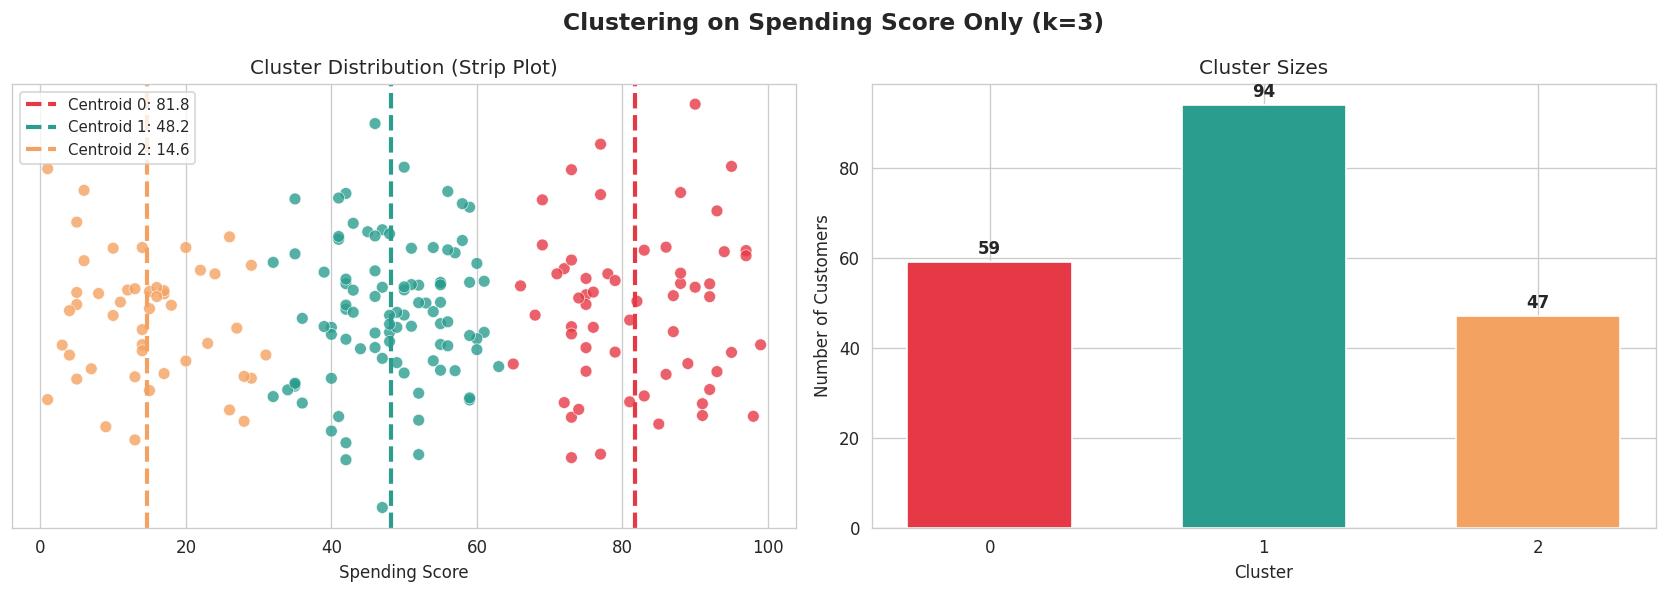

In [40]:
cluster_colors_1d = [PALETTE[c] for c in df['Cluster_1D']]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Clustering on Spending Score Only (k=3)', fontsize=14, fontweight='bold')

# Strip plot (jitter for visibility)
np.random.seed(42)
jitter = np.random.normal(0, 0.05, len(df))
axes[0].scatter(df['Spending_Score'], jitter, c=cluster_colors_1d, s=50, alpha=0.8, edgecolors='white', linewidth=0.4)
for i, c in enumerate(centroids_1d.flatten()):
    axes[0].axvline(c, color=PALETTE[i], linewidth=2.5, linestyle='--', label=f'Centroid {i}: {c:.1f}')
axes[0].set_xlabel('Spending Score')
axes[0].set_yticks([])
axes[0].set_title('Cluster Distribution (Strip Plot)')
axes[0].legend(fontsize=9)

# Cluster size bar chart
sizes_1d = df['Cluster_1D'].value_counts().sort_index()
bars = axes[1].bar(sizes_1d.index, sizes_1d.values, color=[PALETTE[i] for i in sizes_1d.index], edgecolor='white', width=0.6)
axes[1].set_xlabel('Cluster')
axes[1].set_ylabel('Number of Customers')
axes[1].set_title('Cluster Sizes')
axes[1].set_xticks(sizes_1d.index)
for bar in bars:
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, str(int(bar.get_height())),
                 ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.savefig('clusters_1d.png', bbox_inches='tight')
plt.show()

### 5.2 Clustering Visualisation (2 Features)

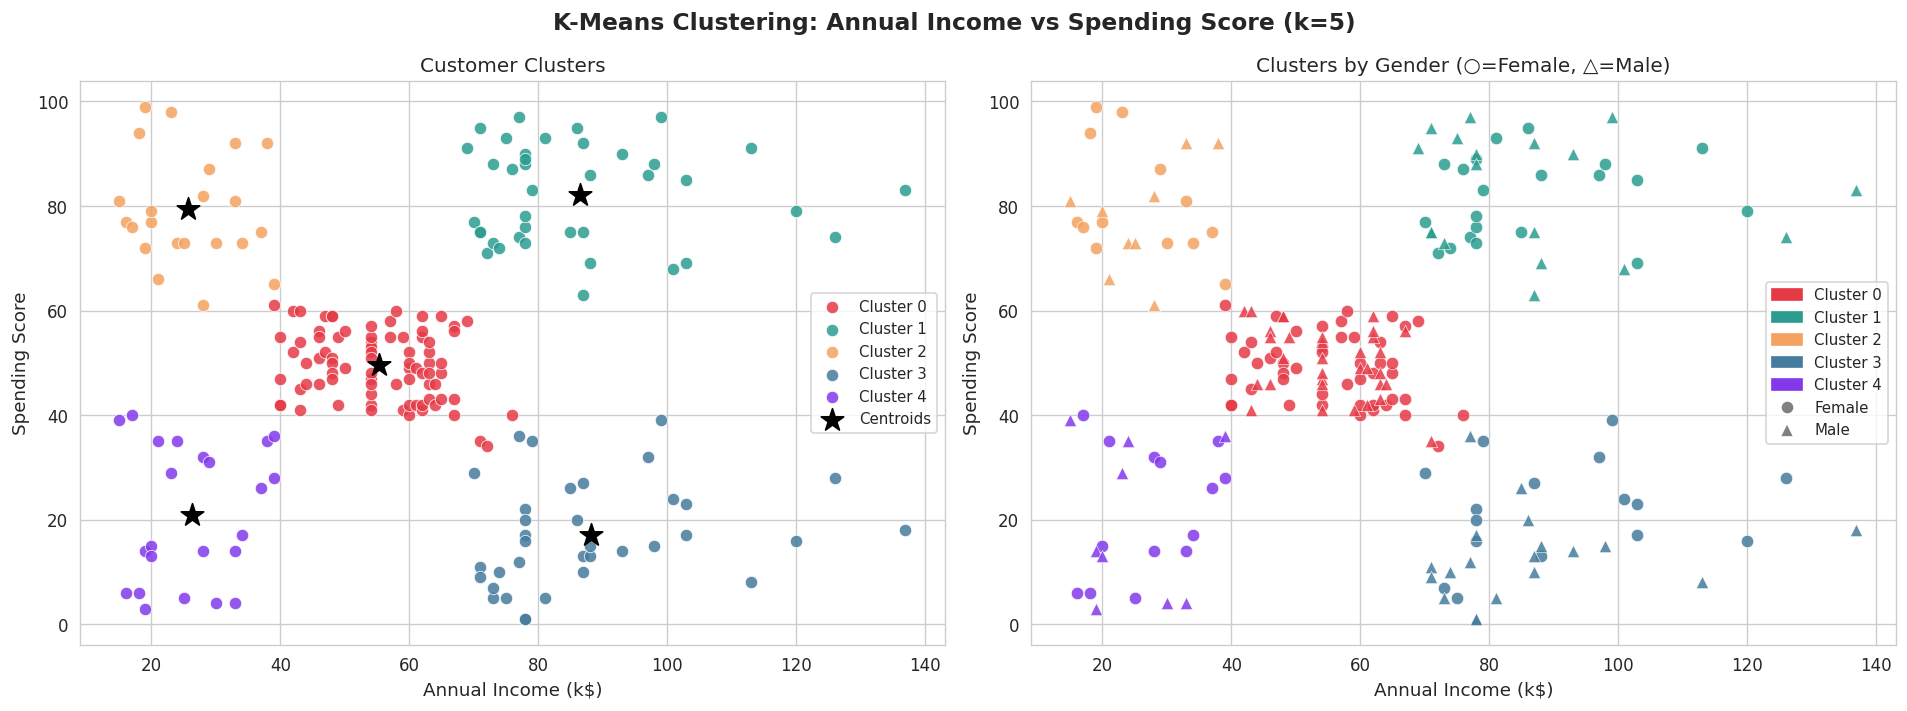

In [41]:
# Map cluster labels to meaningful names based on centroids
centroids_2d_orig = scaler.inverse_transform(km_2d.cluster_centers_)
centroid_df = pd.DataFrame(centroids_2d_orig, columns=['Annual_Income', 'Spending_Score'])

# Label clusters based on income/spending profile
CLUSTER_NAMES = {
    0: 'Cluster 0',
    1: 'Cluster 1',
    2: 'Cluster 2',
    3: 'Cluster 3',
    4: 'Cluster 4'
}

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('K-Means Clustering: Annual Income vs Spending Score (k=5)', fontsize=14, fontweight='bold')

for cluster_id in range(optimal_k_2d):
    mask = df['Cluster_2D'] == cluster_id
    axes[0].scatter(df.loc[mask, 'Annual_Income'], df.loc[mask, 'Spending_Score'],
                    c=PALETTE[cluster_id], s=55, alpha=0.85, edgecolors='white', linewidth=0.5,
                    label=f'Cluster {cluster_id}')

# Plot centroids
axes[0].scatter(centroid_df['Annual_Income'], centroid_df['Spending_Score'],
                c='black', s=200, marker='*', zorder=5, label='Centroids')
axes[0].set_xlabel('Annual Income (k$)', fontsize=11)
axes[0].set_ylabel('Spending Score', fontsize=11)
axes[0].set_title('Customer Clusters')
axes[0].legend(fontsize=9)

# By gender
for cluster_id in range(optimal_k_2d):
    mask = df['Cluster_2D'] == cluster_id
    female = mask & (df['Gender'] == 'Female')
    male   = mask & (df['Gender'] == 'Male')
    axes[1].scatter(df.loc[female, 'Annual_Income'], df.loc[female, 'Spending_Score'],
                    c=PALETTE[cluster_id], s=55, alpha=0.85, marker='o', edgecolors='white', linewidth=0.4)
    axes[1].scatter(df.loc[male, 'Annual_Income'], df.loc[male, 'Spending_Score'],
                    c=PALETTE[cluster_id], s=55, alpha=0.85, marker='^', edgecolors='white', linewidth=0.4)

legend_patches = [mpatches.Patch(color=PALETTE[i], label=f'Cluster {i}') for i in range(optimal_k_2d)]
legend_patches += [plt.Line2D([0],[0], marker='o', color='w', markerfacecolor='gray', markersize=8, label='Female'),
                   plt.Line2D([0],[0], marker='^', color='w', markerfacecolor='gray', markersize=8, label='Male')]
axes[1].legend(handles=legend_patches, fontsize=9)
axes[1].set_xlabel('Annual Income (k$)', fontsize=11)
axes[1].set_ylabel('Spending Score', fontsize=11)
axes[1].set_title('Clusters by Gender (○=Female, △=Male)')

plt.tight_layout()
plt.savefig('clusters_2d.png', bbox_inches='tight')
plt.show()

### 5.3 Side-by-Side Comparison: 1D vs 2D Clustering

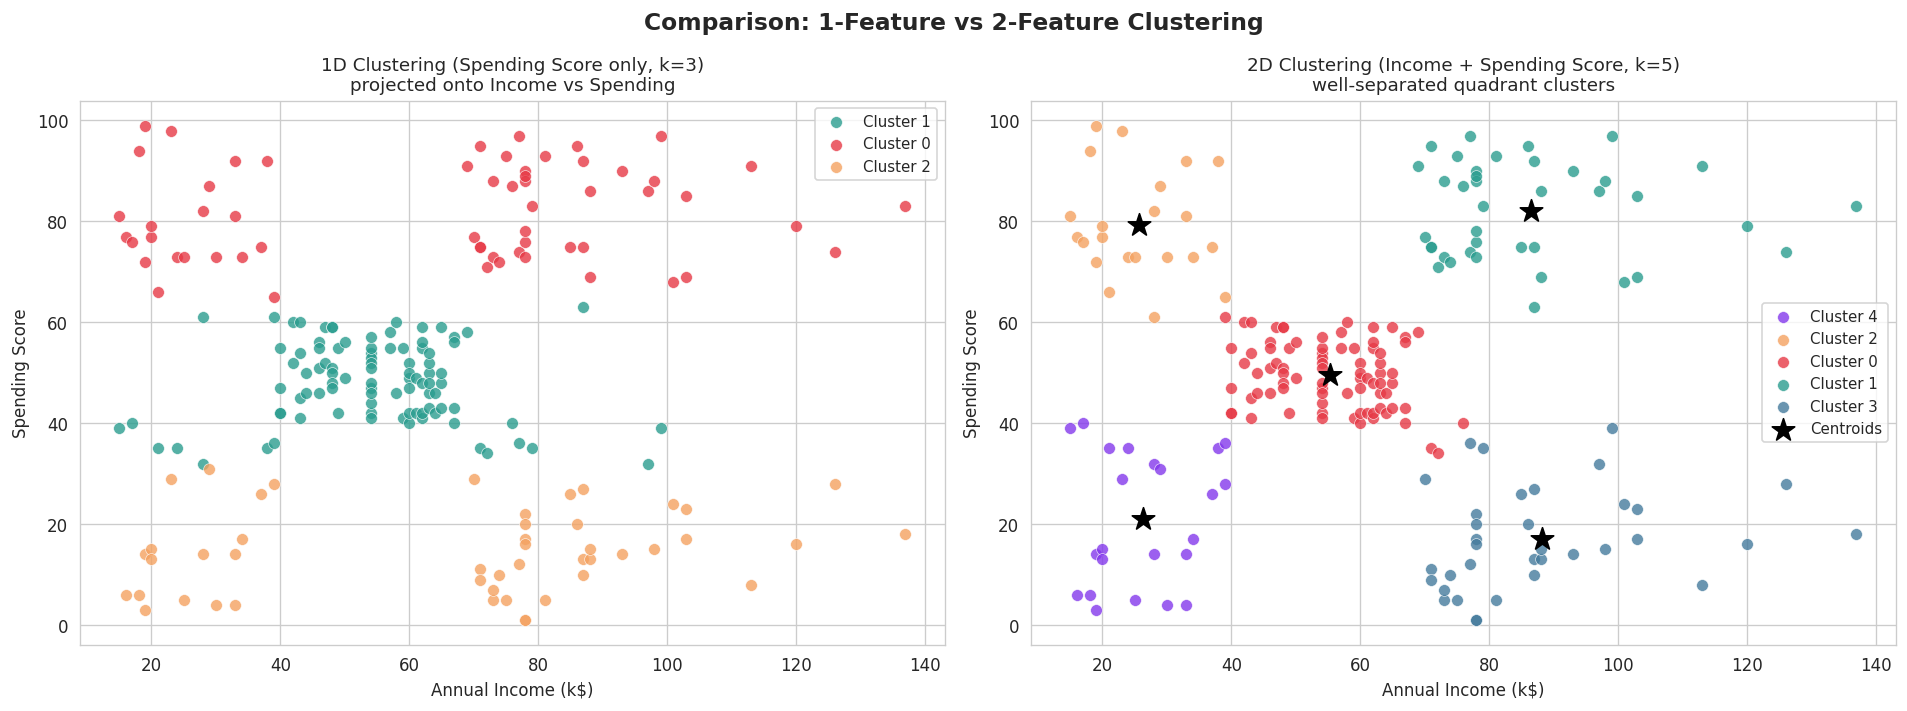

In [42]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Comparison: 1-Feature vs 2-Feature Clustering', fontsize=14, fontweight='bold')

# 1D on Income/Spending space
for c in df['Cluster_1D'].unique():
    m = df['Cluster_1D'] == c
    axes[0].scatter(df.loc[m, 'Annual_Income'], df.loc[m, 'Spending_Score'],
                    color=PALETTE[c], s=50, alpha=0.8, edgecolors='white', linewidth=0.4, label=f'Cluster {c}')
axes[0].set_title('1D Clustering (Spending Score only, k=3)\nprojected onto Income vs Spending', fontsize=11)
axes[0].set_xlabel('Annual Income (k$)')
axes[0].set_ylabel('Spending Score')
axes[0].legend(fontsize=9)

# 2D clusters
for c in df['Cluster_2D'].unique():
    m = df['Cluster_2D'] == c
    axes[1].scatter(df.loc[m, 'Annual_Income'], df.loc[m, 'Spending_Score'],
                    color=PALETTE[c], s=50, alpha=0.8, edgecolors='white', linewidth=0.4, label=f'Cluster {c}')
axes[1].scatter(centroid_df['Annual_Income'], centroid_df['Spending_Score'],
                c='black', s=200, marker='*', zorder=5, label='Centroids')
axes[1].set_title('2D Clustering (Income + Spending Score, k=5)\nwell-separated quadrant clusters', fontsize=11)
axes[1].set_xlabel('Annual Income (k$)')
axes[1].set_ylabel('Spending Score')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.savefig('comparison_1d_vs_2d.png', bbox_inches='tight')
plt.show()

### 5.4 Cluster Profiles Deep-Dive (2D)

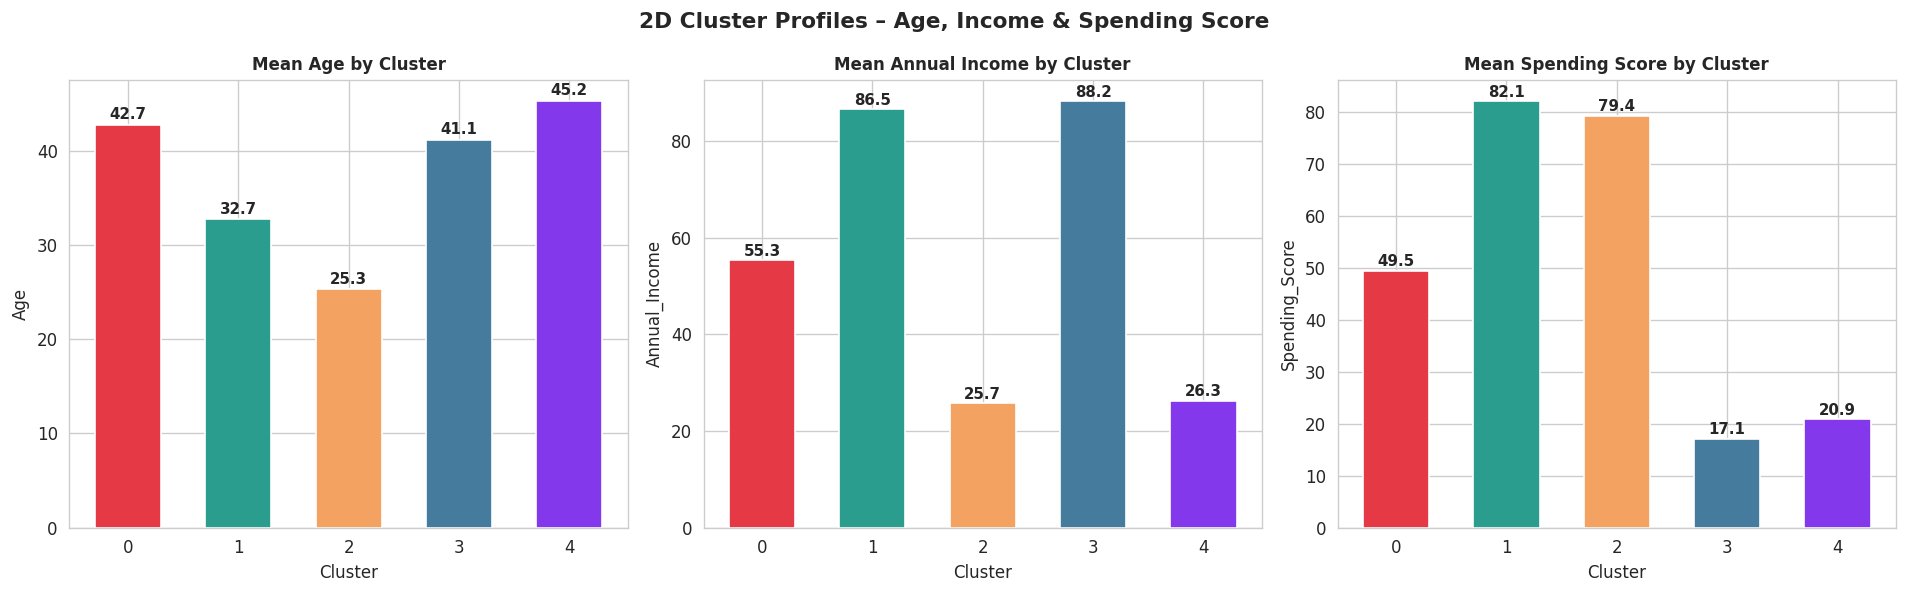

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('2D Cluster Profiles – Age, Income & Spending Score', fontsize=13, fontweight='bold')

metrics = ['Age', 'Annual_Income', 'Spending_Score']
titles  = ['Mean Age by Cluster', 'Mean Annual Income by Cluster', 'Mean Spending Score by Cluster']

for ax, metric, title in zip(axes, metrics, titles):
    vals = df.groupby('Cluster_2D')[metric].mean()
    bars = ax.bar(vals.index, vals.values, color=[PALETTE[i] for i in vals.index], edgecolor='white', width=0.6)
    ax.set_title(title, fontweight='bold', fontsize=10)
    ax.set_xlabel('Cluster')
    ax.set_ylabel(metric)
    ax.set_xticks(vals.index)
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                f'{bar.get_height():.1f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('cluster_profiles_2d.png', bbox_inches='tight')
plt.show()

### 5.5 Commentary on Cluster Distributions

**1D Clustering (Spending Score only, k=3):**
- Produces 3 broad bands: **Low, Medium, High spenders** along the spending score axis.
- When projected onto the Income vs Spending 2D space, the horizontal bands span across all income levels, showing that the clustering ignores income entirely.
- Limited business value — it cannot distinguish a low-income high-spender from a high-income high-spender.

**2D Clustering (Annual Income + Spending Score, k=5):**
- Produces 5 well-separated quadrant-like clusters:

| Cluster | Income | Spending | Profile |
|---------|--------|----------|---------|
| 0 | Medium | Medium | Balanced, average customer |
| 1 | High | Low | Wealthy but cautious spenders |
| 2 | Low | High | Budget earners, high engagement |
| 3 | High | High | Premium, ideal target customers |
| 4 | Low | Low | Low-engagement, infrequent visitors |

- The 2D model yields a **higher silhouette score** and much more actionable segments.
- Each cluster maps directly to a distinct customer persona with different engagement needs.

---
## 6. Customer Engagement Strategy (2D Clusters)

(Question 5). Using a case example of a mall segmenting customers for customer engagement,
use the clustering done in 3b to suggest appropriate ways by which mall
management can interact with their customers.

### 6.1 Assign Persona Labels

In [44]:
# Determine persona per cluster based on centroid analysis
print('=== Centroid Summary ===')
for i, row in centroid_df.iterrows():
    count = (df['Cluster_2D'] == i).sum()
    print(f'Cluster {i} → Income: ${row["Annual_Income"]:.1f}k  |  Spending: {row["Spending_Score"]:.1f}  |  n={count}')

# Assign names dynamically based on centroid ranking
centroid_df['cluster_id'] = centroid_df.index

# Sort to assign labels
high_inc  = centroid_df.nlargest(2, 'Annual_Income')['cluster_id'].tolist()
low_inc   = centroid_df.nsmallest(2, 'Annual_Income')['cluster_id'].tolist()
mid_id    = [i for i in range(5) if i not in high_inc and i not in low_inc][0]

high_inc_high_sp = centroid_df.loc[high_inc].nlargest(1, 'Spending_Score').index[0]
high_inc_low_sp  = [i for i in high_inc if i != high_inc_high_sp][0]
low_inc_high_sp  = centroid_df.loc[low_inc].nlargest(1, 'Spending_Score').index[0]
low_inc_low_sp   = [i for i in low_inc if i != low_inc_high_sp][0]

persona_map = {
    high_inc_high_sp : 'Premium Loyalists',
    high_inc_low_sp  : 'Affluent Browsers',
    low_inc_high_sp  : 'Enthusiastic Savers',
    low_inc_low_sp   : 'Occasional Visitors',
    mid_id           : 'Average Regulars'
}

df['Persona'] = df['Cluster_2D'].map(persona_map)
print('\n=== Persona Assignments ===')
print(df['Persona'].value_counts())

=== Centroid Summary ===
Cluster 0 → Income: $55.3k  |  Spending: 49.5  |  n=81
Cluster 1 → Income: $86.5k  |  Spending: 82.1  |  n=39
Cluster 2 → Income: $25.7k  |  Spending: 79.4  |  n=22
Cluster 3 → Income: $88.2k  |  Spending: 17.1  |  n=35
Cluster 4 → Income: $26.3k  |  Spending: 20.9  |  n=23

=== Persona Assignments ===
Persona
Average Regulars       81
Premium Loyalists      39
Affluent Browsers      35
Occasional Visitors    23
Enthusiastic Savers    22
Name: count, dtype: int64


### 6.2 Persona Visualisation

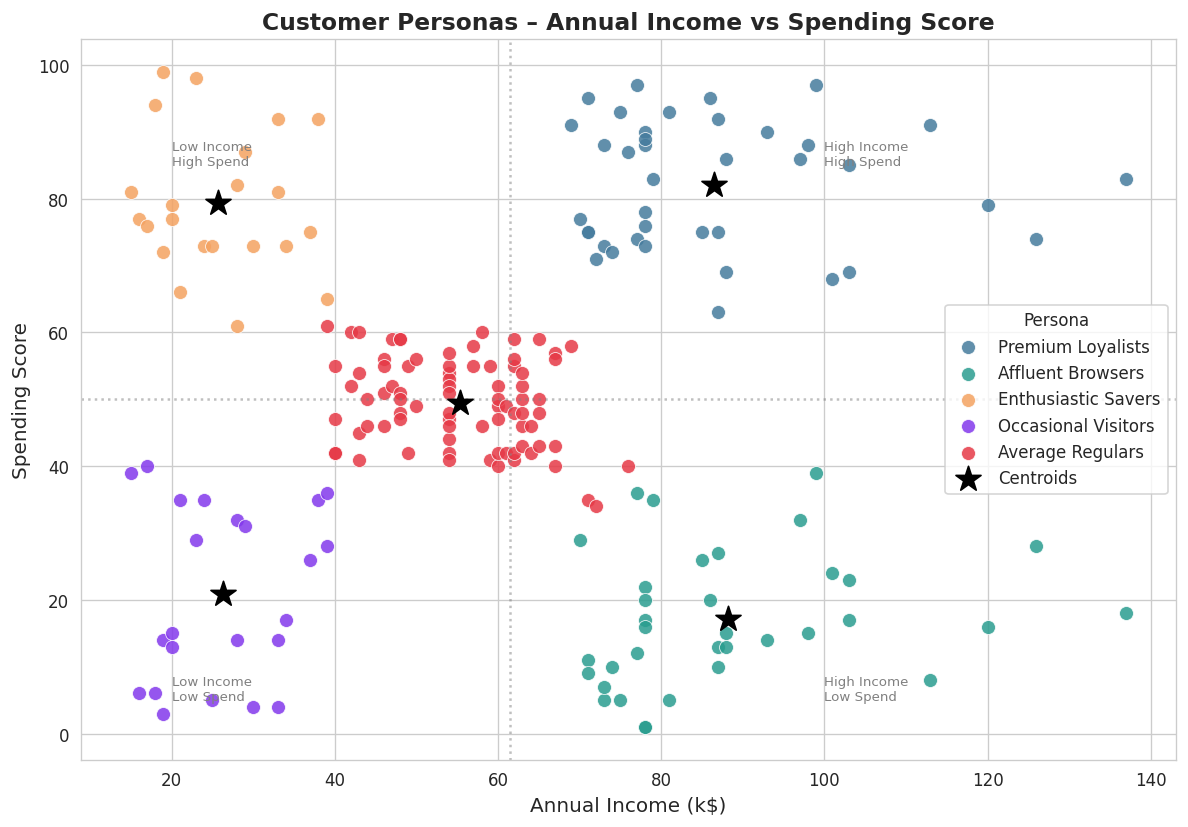

In [45]:
persona_colors = {
    'Premium Loyalists'   : PALETTE[3],
    'Affluent Browsers'   : PALETTE[1],
    'Enthusiastic Savers' : PALETTE[2],
    'Occasional Visitors' : PALETTE[4],
    'Average Regulars'    : PALETTE[0]
}

fig, ax = plt.subplots(figsize=(10, 7))

for persona, color in persona_colors.items():
    mask = df['Persona'] == persona
    ax.scatter(df.loc[mask, 'Annual_Income'], df.loc[mask, 'Spending_Score'],
               c=color, s=70, alpha=0.85, edgecolors='white', linewidth=0.5, label=persona)

ax.scatter(centroid_df['Annual_Income'], centroid_df['Spending_Score'],
           c='black', s=250, marker='*', zorder=5, label='Centroids')

ax.set_xlabel('Annual Income (k$)', fontsize=12)
ax.set_ylabel('Spending Score', fontsize=12)
ax.set_title('Customer Personas – Annual Income vs Spending Score', fontsize=14, fontweight='bold')
ax.legend(title='Persona', fontsize=10, title_fontsize=10)

# Quadrant shading
mid_inc = df['Annual_Income'].median()
mid_sp  = df['Spending_Score'].median()
ax.axvline(mid_inc, color='gray', linestyle=':', alpha=0.5)
ax.axhline(mid_sp,  color='gray', linestyle=':', alpha=0.5)
ax.text(20,  85, 'Low Income\nHigh Spend',  fontsize=8, color='gray')
ax.text(100, 85, 'High Income\nHigh Spend', fontsize=8, color='gray')
ax.text(20,  5,  'Low Income\nLow Spend',   fontsize=8, color='gray')
ax.text(100, 5,  'High Income\nLow Spend',  fontsize=8, color='gray')

plt.tight_layout()
plt.savefig('customer_personas.png', bbox_inches='tight')
plt.show()

### 6.3 Mall Engagement Strategy by Customer Persona

---

####  Cluster: Premium Loyalists
**(High Income + High Spending Score)**

**Profile:** These are the mall's most valuable customers. They earn well and spend freely, indicating strong brand affinity and shopping enthusiasm.

**Engagement Strategy:**
- **VIP Loyalty Programme:** Offer a tiered rewards card with exclusive benefits — early sale access, complimentary valet parking, personal shopping assistants.
- **Premium Event Invitations:** Invite to private brand launch events, wine & dine evenings, and fashion previews hosted in the mall.
- **Personalised Concierge Notifications:** Push personalised alerts for new arrivals at premium stores they frequent.
- **Exclusive Partnerships:** Provide concierge links to luxury services (travel, fine dining, spa bookings) through the mall app.

---

####  Cluster: Affluent Browsers
**(High Income + Low Spending Score)**

**Profile:** Earn a lot but spend sparingly. They visit the mall but are not converting their earning potential into purchases. They may be value-conscious, indecisive, or unaware of relevant offers.

**Engagement Strategy:**
- **Targeted Premium Promotions:** Send curated discount offers on high-end products that match their browsing/purchase history via the mall app.
- **Exclusive Bundle Deals:** Create premium bundles (e.g., electronics + luxury accessories) that appeal to value-conscious high earners.
- **Experiential Demonstrations:** Set up interactive demos (e.g., tech showcases, luxury car displays, gourmet tastings) to re-engage their interest.
- **Personalised Reminders:** Use email or SMS to follow up on products they viewed but did not purchase (cart recovery approach for physical retail).

---

####  Cluster: Enthusiastic Savers
**(Low Income + High Spending Score)**

**Profile:** Despite modest incomes, these customers love shopping and spend a large share of their budget in the mall. They are trend-conscious, deal-hunters, and emotionally engaged shoppers.

**Engagement Strategy:**
- **Flash Sales & Limited-Time Offers:** Notify this group first about daily/weekly flash deals, clearance sales, and bundle discounts.
- **Points-Based Loyalty Rewards:** Ensure they feel rewarded frequently — micro-rewards for every visit (e.g., bonus points, free snacks, small gift vouchers).
- **Social Media Engagement:** Run Instagram/TikTok campaigns where in-mall purchases earn sharable rewards — this group is often socially active.
- **Instalment & Buy-Now-Pay-Later Plans:** Partner with BNPL providers to allow purchases of aspirational items, reducing immediate financial barriers.

---

####  Cluster: Average Regulars
**(Medium Income + Medium Spending Score)**

**Profile:** The broad middle market — steady, predictable visitors who represent the bulk of consistent foot traffic. They respond well to general promotions.

**Engagement Strategy:**
- **Seasonal Campaign Bundles:** Run broad seasonal campaigns (Back-to-School, Holiday, Black Friday) with multi-store bundled discounts.
- **Family & Lifestyle Events:** Host family-friendly events (food festivals, movie nights, kids' activities) to drive longer dwell time and higher spending.
- **Cross-Store Voucher Schemes:** Issue spend-and-save vouchers redeemable across multiple stores to encourage diversified purchasing.
- **Weekly Newsletters:** Keep them informed via email about what's new in the mall — events, new store openings, featured brands.

---

####  Cluster: Occasional Visitors
**(Low Income + Low Spending Score)**

**Profile:** Visit infrequently and spend minimally. They may be window shoppers, utility visitors (food court, services), or price-sensitive customers who need stronger incentives.

**Engagement Strategy:**
- **Free & Low-Cost Experience Activations:** Attract with free events (live music, free workshops, giveaways) that build a habit of visiting the mall.
- **Entrance-Level Promotions:** Position budget-friendly brands and affordable dining options prominently to make the mall feel accessible.
- **Referral Rewards:** Encourage word-of-mouth through referral incentives — invite a friend, both get a discount.
- **Digital Engagement:** Use cost-effective WhatsApp/SMS marketing with time-sensitive discount codes to drive spontaneous visits.

---

### 6.4 Strategic Priority Summary

In [46]:
strategy_data = {
    'Persona'              : ['Premium Loyalists','Affluent Browsers','Enthusiastic Savers','Average Regulars','Occasional Visitors'],
    'Revenue Potential'    : ['⭐⭐⭐⭐⭐','⭐⭐⭐⭐⭐','⭐⭐⭐','⭐⭐⭐','⭐'],
    'Retention Priority'   : ['Critical','High','High','Medium','Low'],
    'Key Channel'          : ['App + In-Person VIP','App + Email','Social Media + App','Email + In-Mall Events','SMS + Free Events'],
    'Primary Goal'         : ['Deepen loyalty','Increase conversion','Sustain & reward','Diversify spend','Build habit & trust']
}

strat_df = pd.DataFrame(strategy_data)
print('\n=== Mall Customer Engagement Strategy Matrix ===')
print(strat_df.to_string(index=False))


=== Mall Customer Engagement Strategy Matrix ===
            Persona Revenue Potential Retention Priority            Key Channel        Primary Goal
  Premium Loyalists             ⭐⭐⭐⭐⭐           Critical    App + In-Person VIP      Deepen loyalty
  Affluent Browsers             ⭐⭐⭐⭐⭐               High            App + Email Increase conversion
Enthusiastic Savers               ⭐⭐⭐               High     Social Media + App    Sustain & reward
   Average Regulars               ⭐⭐⭐             Medium Email + In-Mall Events     Diversify spend
Occasional Visitors                 ⭐                Low      SMS + Free Events Build habit & trust


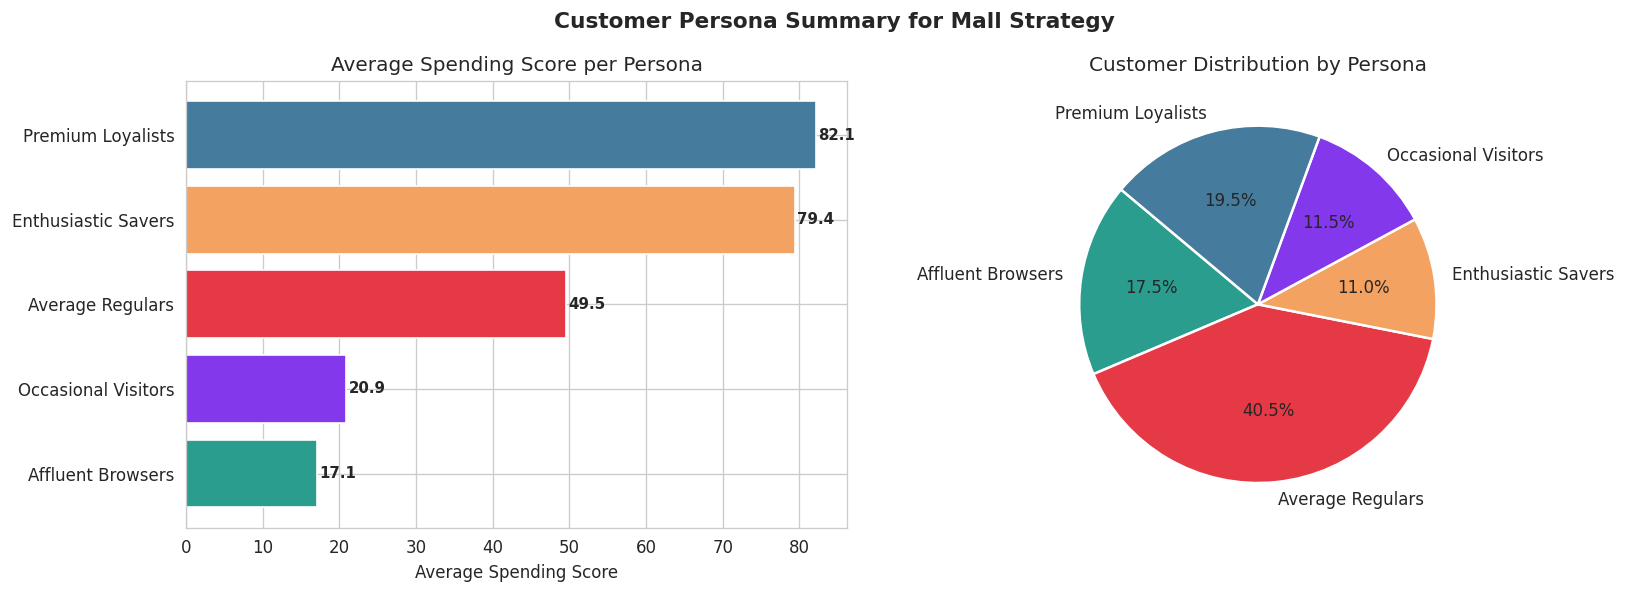


 Analysis Complete!


In [47]:
# Final revenue contribution visualisation
avg_spend = df.groupby('Persona')['Spending_Score'].mean().sort_values(ascending=True)
counts    = df.groupby('Persona').size()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Customer Persona Summary for Mall Strategy', fontsize=13, fontweight='bold')

colors = [persona_colors.get(p, '#999') for p in avg_spend.index]
bars = axes[0].barh(avg_spend.index, avg_spend.values, color=colors, edgecolor='white')
axes[0].set_xlabel('Average Spending Score')
axes[0].set_title('Average Spending Score per Persona')
for bar in bars:
    axes[0].text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
                 f'{bar.get_width():.1f}', va='center', fontsize=9, fontweight='bold')

count_colors = [persona_colors.get(p, '#999') for p in counts.index]
axes[1].pie(counts.values, labels=counts.index, autopct='%1.1f%%',
            colors=count_colors, startangle=140,
            wedgeprops=dict(edgecolor='white', linewidth=1.5))
axes[1].set_title('Customer Distribution by Persona')

plt.tight_layout()
plt.savefig('strategy_summary.png', bbox_inches='tight')
plt.show()

print('\n Analysis Complete!')

##Screenshot of Meeting

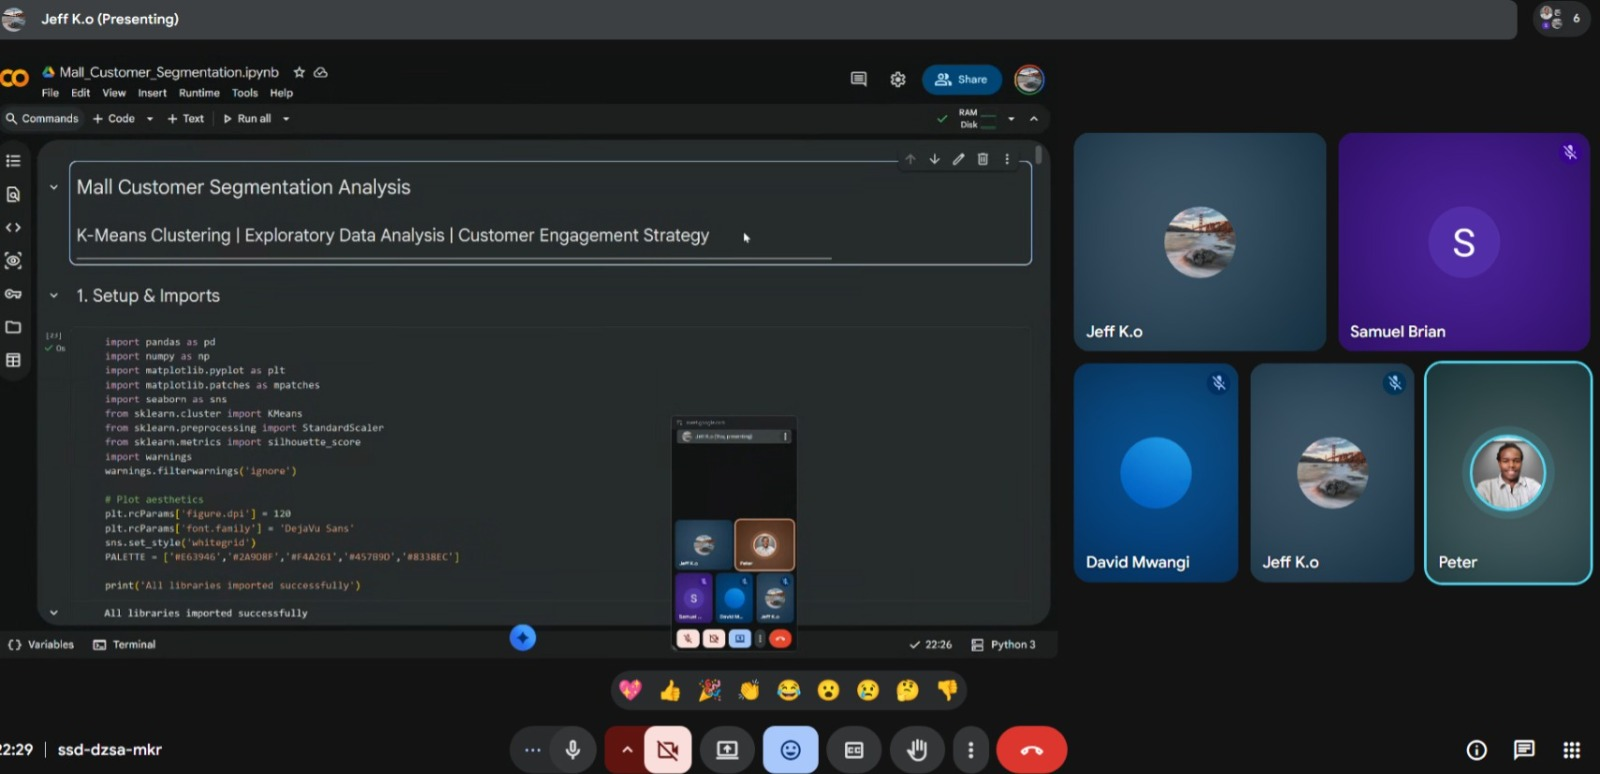
